# SHAP & Counterfactual Explainability —  Shooting Biomechanics


The pipeline is a three-stage causal chain:

```
Biomechanics  →  Ball Flight  →  Miss Distance
                            ↘
                              P(Made / BDFC)   (parallel sanity check)
```

## IMPORTANT LOOP NOTE
Sections **8 (Player analysis)**, **9 (Counterfactual recommendations)**, and **11 (Unity export)** are currently written as a **single-player flow** (`PLAYER_ID = 'Player 163'`).

A **mid-file loop-control cell** is included before Section 9. It defaults to `RUN_ALL_PLAYERS = False` so current behavior stays single-player. Set it to `True` if you want to process all `PlayerID`s, then run the **optional all-player batch cell after Section 11**.

## What's new vs `phillip/shap_model`

**Methodology**
- `GroupKFold(groups=PlayerID)` for all CV R² — random folds leaked Player 163's 13% data share into every split.
- Sentinel cleanup: 8 alignment columns had `-1e9` markers blowing std into the millions.
- Circular std (`scipy.stats.circstd`) for `*Alignment*` features — linear std mishandles ±180° wrap.
- Per-player sample cap (500 shots) so no single player dominates the loss.

**Stage 3 redesign**
- Switched the direct outcome from `Made` (binary, AUC) to `Ball.Distance.from.Center` (continuous, R²). More information per shot.
- Added a free-throw parallel pipeline as a clean-conditions sanity check.

**Feature engineering**
- Within-player z-scores (`__zwithin`) for the consistency signal.
- Dom/NonDom symmetry diffs.
- Year + DaysSinceFirstShot.
- Unlocked release-point biomech features (`BallXRelease`, etc.) that the old `'ball'` substring filter was silently dropping.
- Height-normalized release height replaces raw `Release.Height` to drop the stature confound.

**Coaching framework**
- Optimal-band targets (40–60 pctile of *made shots only*, not top quartile of all shots — entry angle / arc / velocity have optima, not maxima).
- Make/miss self-comparison gate that surfaces priorities even when no ball-flight gap fires.
- Consistency analysis vs height-matched peers.
- DiCE counterfactuals filtered by anatomical caps, per-player feasibility, kNN plausibility, and coachability scoring. Genetic method instead of random sampling.

**Output**
- Per-shot Unity-ready CSV with `orig_` / `rec_` pose pairs.

## Sections
1. Setup & data loading
2. Preprocessing (handedness, sentinel cleanup, FT filter)
3. Feature engineering
4. Stage 1 models — biomech → ball flight
5. Global SHAP
6. Stage 2 — ball flight → miss distance
7. Stage 3 sanity check — direct biomech → BDFC
8. Player analysis
9. Counterfactual recommendations
10. Free-throw sanity check
11. Unity export
12. Summary


## 1. Setup

In [8]:
import os, re, joblib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import shap
import dice_ml
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler
from scipy.stats import circstd, spearmanr

warnings.filterwarnings('ignore')
shap.initjs()
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')


In [9]:
CSV_CANDIDATES = [
    'capstone2026v2.csv',
    '../capstone2026v2.csv',
    '/Users/shahil/Documents/UCSB/2025-2026/P3/capstone2026v2.csv',
]
DATA_PATH = next((p for p in CSV_CANDIDATES if os.path.exists(p)), None)
if DATA_PATH is None:
    raise FileNotFoundError('capstone2026v2.csv not found in any expected location.')

df_raw = pd.read_csv(DATA_PATH).rename(columns={'Name': 'PlayerID'})
print(f'Loaded {len(df_raw):,} shots × {df_raw.shape[1]} cols  |  '
      f'{df_raw.PlayerID.nunique()} players  |  '
      f'{df_raw.Date.min()} → {df_raw.Date.max()}')


Loaded 25,868 shots × 264 cols  |  165 players  |  1/18/2025 14:17 → 9/9/2024 9:18


## 2. Preprocessing

Three things happen here: handedness normalization (so all biomech features refer to the dominant side), sentinel-value cleanup, and the jump-shot filter.

The handedness logic reflects left-handed players into a right-handed reference frame and renames Left/Right columns to NonDominant/Dominant. After this step, "Dominant" always means the shooting hand.


In [10]:
def _reflect_across_shot_axis(x, y):
    n = np.sqrt(x**2 + y**2)
    if n == 0:
        return x, y
    ux, uy = x / n, y / n
    px, py = (x*ux + y*uy) * ux, (x*ux + y*uy) * uy
    return x - 2*(x - px), y - 2*(y - py)


def standardize_handedness(df):
    df = df.copy()
    left = df['hand'] == 'Left'

    coords = df.loc[left, ['Shot.X.Pos', 'Shot.Y.Pos']].values
    if len(coords) > 0:
        ref = np.array([_reflect_across_shot_axis(x, y) for x, y in coords])
        df.loc[left, 'Shot.X.Pos'] = ref[:, 0]
        df.loc[left, 'Shot.Y.Pos'] = ref[:, 1]
    df.loc[left, 'Shot.X.Pos'] *= -1

    x_cols = [c for c in df.columns if re.search(r'(^|_)X($|[A-Z])', c)]
    y_cols = [c for c in df.columns if re.search(r'(^|_)Y($|[A-Z])', c)]
    for x_col, y_col in zip(x_cols, y_cols):
        coords = df.loc[left, [x_col, y_col]].values
        if len(coords) > 0:
            ref = np.array([_reflect_across_shot_axis(x, y) for x, y in coords])
            df.loc[left, x_col] = ref[:, 0]
            df.loc[left, y_col] = ref[:, 1]
        df.loc[left, x_col] *= -1

    for left_col in [c for c in df.columns if 'Left' in c]:
        right_col = left_col.replace('Left', 'Right')
        if right_col in df.columns:
            tmp = df.loc[left, left_col].copy()
            df.loc[left, left_col] = df.loc[left, right_col]
            df.loc[left, right_col] = tmp

    rename = {c: c.replace('Right', 'Dominant') for c in df.columns if 'Right' in c}
    rename.update({c: c.replace('Left', 'NonDominant') for c in df.columns if 'Left' in c})
    return df.rename(columns=rename)


In [11]:
SHOT_GROUP = 'JumpShots'   # 'JumpShots' | 'FreeThrow' | 'All'

df = standardize_handedness(df_raw)

# Sentinel cleanup -- 8 alignment cols had -1e9 markers (10 rows total).
num_cols = df.select_dtypes('number').columns
n_sentinels = int((df[num_cols].abs() > 1e6).sum().sum())
df[num_cols] = df[num_cols].mask(df[num_cols].abs() > 1e6)
print(f'Cleaned {n_sentinels} sentinel cells (|x| > 1e6 → NaN)')

# Free throws are mechanically distinct -- model them separately.
if SHOT_GROUP == 'JumpShots':
    df = df[df['Shot.Location'] != 'Free Throw'].copy()
elif SHOT_GROUP == 'FreeThrow':
    df = df[df['Shot.Location'] == 'Free Throw'].copy()

# Height-normalized release: drops the "tall players release high" trivial signal
if {'Release.Height', 'ht'}.issubset(df.columns):
    df['Release.Height.Norm'] = df['Release.Height'] / df['ht']

# Temporal features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['DaysSinceFirstShot'] = (df['Date'] - df.groupby('PlayerID')['Date'].transform('min')).dt.days

print(f'{SHOT_GROUP}: {len(df):,} shots × {df.PlayerID.nunique()} players')


Cleaned 10 sentinel cells (|x| > 1e6 → NaN)
JumpShots: 21,901 shots × 165 players


## 3. Feature engineering

`X_full` has four feature families. Only `BIOMECH_FEATURES` is exposed to DiCE for counterfactual generation — those are the ones a coach can actually act on. The others help the model condition properly.

| Family | What it captures |
|---|---|
| `BIOMECH_FEATURES` | Raw joint angles, ROMs, velocities |
| `__zwithin` | Per-player z-scores — within-player consistency signal |
| `DomDiff` | Dom − NonDom asymmetry |
| Context | Shot.Distance, shot type one-hots, Year |


In [12]:
BIO_KEYWORDS = ['ankle','knee','hip','shoulder','elbow','torso','wrist',
                'flexion','extension','alignment','rom','velocity','velo',
                'dorsiflexion','plantarflexion','stance','gap']
EXCLUDE_KEYWORDS = ['time','made','shot.location','shot.type','shot.x','shot.y',
                    'pos.x','pos.y','pos.z','distance.from','date','name','playerid','hand']
KNOWN_TARGETS = {
    'Ball_to_Rim_Angle','Ball_Velocity','Release.Height','Release.Height.Norm',
    'Initial.Ball.Angle','Initial.Ball.Velocity','Max.Ball.Arc',
    'Made','Ball.Distance.from.Center','Shot.X.Pos','Shot.Y.Pos',
}


def select_biomech(df):
    """Pick biomechanical feature columns by token match (so 'x' won't match 'flexion')."""
    out = []
    for c in df.columns:
        if c in KNOWN_TARGETS:
            continue
        cl = c.lower()
        tokens = set(re.split(r'[._\- ]+', cl))
        if tokens & set(EXCLUDE_KEYWORDS):
            continue
        if any(k in cl for k in BIO_KEYWORDS):
            out.append(c)
    return out


def add_within_player(df, cols, group='PlayerID'):
    """Adds <col>__zwithin = (col - player_mean) / player_std."""
    out = df.copy()
    for c in cols:
        if c not in df.columns:
            continue
        m = df.groupby(group)[c].transform('mean')
        s = df.groupby(group)[c].transform('std').replace(0, np.nan)
        out[f'{c}__zwithin'] = ((df[c] - m) / s).fillna(0)
    return out


def add_symmetry(df):
    """Dom - NonDom diff for each paired column. (Ratios were tested and add no held-out signal.)"""
    out = df.copy()
    new = []
    for c in df.columns:
        if 'NonDominant' in c or 'Dominant' not in c:
            continue
        partner = c.replace('Dominant', 'NonDominant')
        if partner in df.columns:
            diff = c.replace('Dominant', 'DomDiff')
            out[diff] = df[c] - df[partner]
            new.append(diff)
    return out, new


In [13]:
BIOMECH_FEATURES = list(df[select_biomech(df)].select_dtypes('number').columns)

df = add_within_player(df, BIOMECH_FEATURES)
ZWITHIN_FEATURES = [f'{c}__zwithin' for c in BIOMECH_FEATURES if f'{c}__zwithin' in df.columns]

df, SYMMETRY_FEATURES = add_symmetry(df)

ctx_pieces, ctx_names = [], []
if 'Shot.Distance' in df.columns:
    ctx_pieces.append(df[['Shot.Distance']]); ctx_names.append('Shot.Distance')
if 'Shot.Type' in df.columns:
    st = pd.get_dummies(df['Shot.Type'], prefix='ShotType', dtype=int)
    ctx_pieces.append(st); ctx_names += st.columns.tolist()
if 'Year' in df.columns:
    ctx_pieces.append(df[['Year', 'DaysSinceFirstShot']])
    ctx_names += ['Year', 'DaysSinceFirstShot']
CONTEXT_FEATURES = ctx_names

X_full = pd.concat([df[BIOMECH_FEATURES], df[ZWITHIN_FEATURES],
                    df[SYMMETRY_FEATURES] if SYMMETRY_FEATURES else None,
                    *ctx_pieces], axis=1)
X_full = X_full.loc[:, ~X_full.columns.duplicated()]

print(f'X_full = {X_full.shape[1]} cols  '
      f'(biomech {len(BIOMECH_FEATURES)} + zwithin {len(ZWITHIN_FEATURES)} + '
      f'symmetry {len(SYMMETRY_FEATURES)} + context {len(CONTEXT_FEATURES)})')

counts = df.PlayerID.value_counts()
print(f'Shots/player: median {counts.median():.0f}  max {counts.max()}  '
      f'(top: {counts.index[0]}, {counts.iloc[0]/len(df):.1%} of dataset)')


X_full = 546 cols  (biomech 206 + zwithin 206 + symmetry 130 + context 5)
Shots/player: median 76  max 2873  (top: Player 163, 13.1% of dataset)


## 4. Stage 1 — Biomechanics → Ball Flight

LightGBM regressor per ball-flight target. Held-out R² uses `GroupKFold(groups=PlayerID)` so a player never appears in both train and test. We also cap any single player at 500 shots before fitting — Player 163 alone has 13% of the data, and without the cap the model would essentially be predicting his shots.

`R2_MIN_FOR_DICE = 0.20` is the gate for downstream counterfactual generation. Below that, recommendations would be noise.


In [15]:
BALL_FLIGHT_TARGETS = [
    'Release.Height.Norm', 'Initial.Ball.Angle',
    'Initial.Ball.Velocity', 'Max.Ball.Arc',
]
R2_MIN_FOR_DICE = 0.20
PER_PLAYER_CAP = 500
MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)


def cap_per_player(X, y, groups, cap=PER_PLAYER_CAP, seed=42):
    if cap is None:
        return X, y, groups
    rng = np.random.default_rng(seed)
    g = pd.Series(groups, index=X.index)
    keep = pd.Series(True, index=X.index)
    for player, n in g.value_counts().items():
        if n > cap:
            idx = X.index[g == player]
            drop = rng.choice(idx.values, size=n - cap, replace=False)
            keep.loc[drop] = False
    return X[keep], y[keep], np.asarray(groups)[keep.values]


models, metrics, X_per_target, y_per_target = {}, {}, {}, {}

for target in BALL_FLIGHT_TARGETS:
    if target not in df.columns:
        continue
    cache = os.path.join(MODEL_DIR, f'lgbm_{SHOT_GROUP}_{target.replace(".","_")}.pkl')

    data = pd.concat([X_full, df[target]], axis=1).dropna()
    X_clean, y_clean = data[X_full.columns], data[target]
    g_clean = df.loc[X_clean.index, 'PlayerID'].values

    X_fit, y_fit, g_fit = cap_per_player(X_clean, y_clean, g_clean)

    # Always retrain to ensure feature compatibility with current X_full
    model = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
    model.fit(X_fit, y_fit)
    joblib.dump(model, cache)
    src = 'trained'

    preds = model.predict(X_clean)
    r2_train = r2_score(y_clean, preds)
    mae = mean_absolute_error(y_clean, preds)
    rmse = np.sqrt(mean_squared_error(y_clean, preds))

    cv_est = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
    r2_cv = float(np.mean(cross_val_score(
        cv_est, X_fit, y_fit,
        cv=GroupKFold(5).split(X_fit, y_fit, groups=g_fit),
        scoring='r2', n_jobs=-1
    )))

    models[target] = model
    metrics[target] = {'R2': r2_cv, 'R2_train': r2_train, 'MAE': mae, 'RMSE': rmse}
    X_per_target[target] = X_clean
    y_per_target[target] = y_clean

    flag = '' if r2_cv >= R2_MIN_FOR_DICE else f'  (below R²_MIN, DiCE will skip)'
    print(f'[{src}] {target:24s}  R²_cv={r2_cv:.3f}  R²_train={r2_train:.3f}  '
          f'MAE={mae:.4f}  RMSE={rmse:.4f}{flag}')

pd.DataFrame(metrics).T.round(4).style.background_gradient(subset=['R2'], cmap='RdYlGn')


[trained] Release.Height.Norm       R²_cv=0.670  R²_train=0.972  MAE=0.0003  RMSE=0.0004
[trained] Initial.Ball.Angle        R²_cv=0.531  R²_train=0.890  MAE=0.8022  RMSE=1.4036
[trained] Initial.Ball.Velocity     R²_cv=0.875  R²_train=0.975  MAE=0.0712  RMSE=0.1366
[trained] Max.Ball.Arc              R²_cv=0.550  R²_train=0.956  MAE=0.0513  RMSE=0.0744


,R2,R2_train,MAE,RMSE
Release.Height.Norm,0.670400,0.972000,0.000300,0.000400
Initial.Ball.Angle,0.531300,0.889700,0.802200,1.403600
Initial.Ball.Velocity,0.875500,0.975200,0.071200,0.136600
Max.Ball.Arc,0.550400,0.955700,0.051300,0.074400


## 5. Global SHAP — biomech features driving ball flight

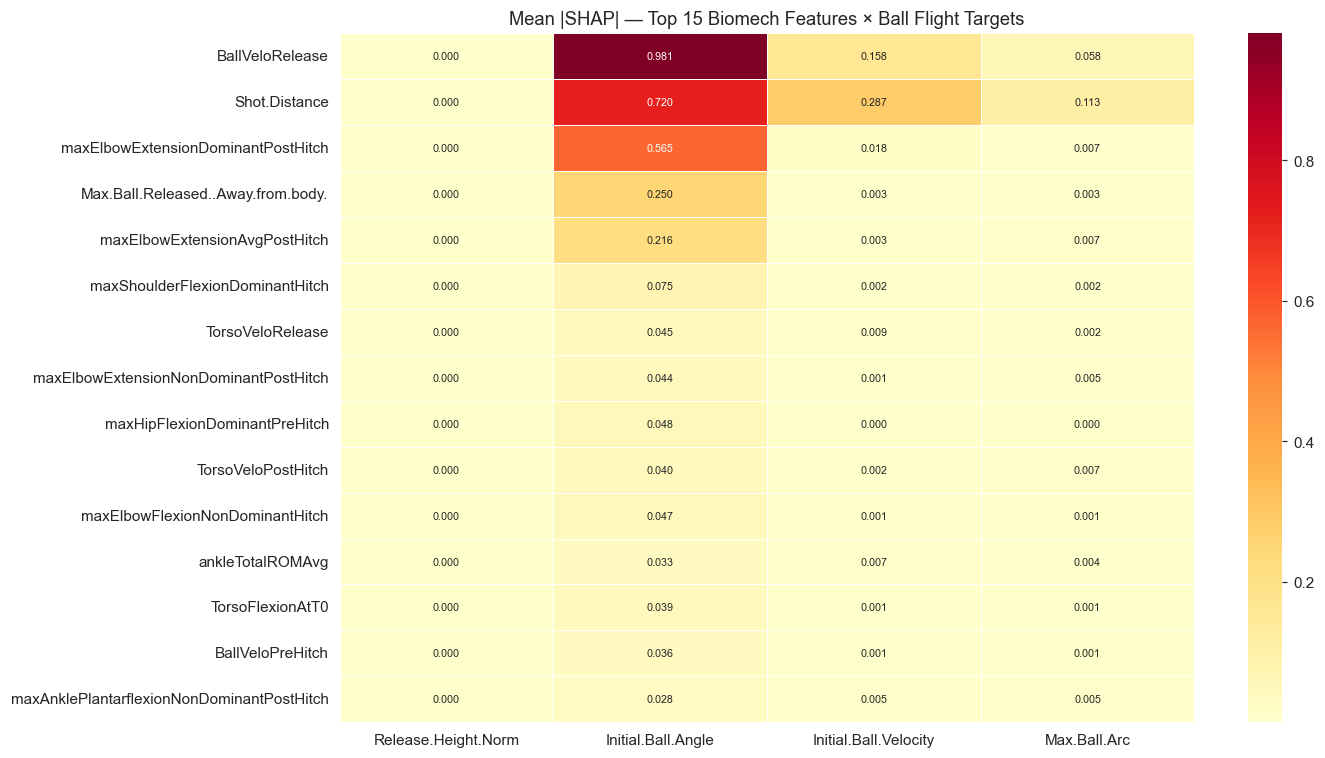

In [16]:
SHAP_SAMPLE = 5000
shap_values_dict, explainers_dict, shap_samples_dict = {}, {}, {}

for target in BALL_FLIGHT_TARGETS:
    X = X_per_target[target]
    samp = X.sample(min(SHAP_SAMPLE, len(X)), random_state=42)
    expl = shap.TreeExplainer(models[target])
    sv = expl.shap_values(samp)
    shap_values_dict[target] = sv
    explainers_dict[target] = expl
    shap_samples_dict[target] = samp

# Cross-target ranking
ranks = []
for t in BALL_FLIGHT_TARGETS:
    s = pd.Series(np.abs(shap_values_dict[t]).mean(axis=0),
                  index=shap_samples_dict[t].columns, name=t)
    ranks.append(s)
cross_df = pd.concat(ranks, axis=1)
cross_df['mean_rank'] = cross_df.mean(axis=1)
cross_df = cross_df.sort_values('mean_rank', ascending=False)

biomech_cross = cross_df[cross_df.index.isin(BIOMECH_FEATURES)]

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(biomech_cross.head(15)[BALL_FLIGHT_TARGETS],
            cmap='YlOrRd', ax=ax, linewidths=0.4, annot=True, fmt='.3f',
            annot_kws={'size': 7})
ax.set_title('Mean |SHAP| — Top 15 Biomech Features × Ball Flight Targets', fontsize=12)
plt.tight_layout()
plt.show()


## 6. Stage 2 — Ball Flight → Miss Distance

One Random Forest per `(Shot.Location, Shot.Type)` group with `n ≥ 100`. This is the strongest layer of the chain — once a shot leaves the hand with measurable initial conditions, miss distance is highly predictable across all shot contexts.


20 groups  |  R² range: 0.853–0.888  (median 0.873)


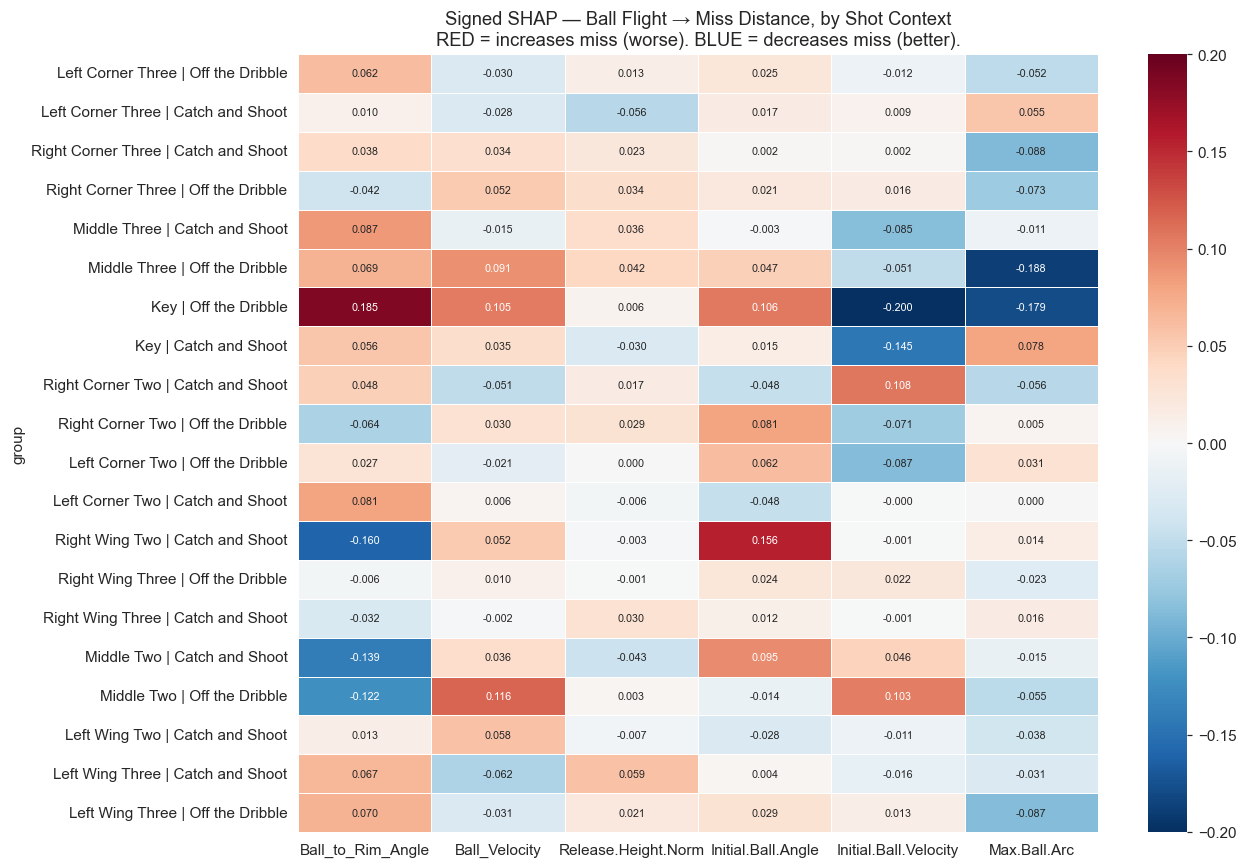

In [17]:
PREDICTORS = ['Ball_to_Rim_Angle','Ball_Velocity','Release.Height.Norm',
              'Initial.Ball.Angle','Initial.Ball.Velocity','Max.Ball.Arc']
BDFC = 'Ball.Distance.from.Center'
MIN_N = 100

groups = []
for loc in df['Shot.Location'].unique():
    if loc == 'Free Throw':
        sub = df[df['Shot.Location'] == loc]
        if len(sub) >= MIN_N:
            groups.append((loc, 'All', sub))
    else:
        for st in df[df['Shot.Location'] == loc]['Shot.Type'].unique():
            sub = df[(df['Shot.Location'] == loc) & (df['Shot.Type'] == st)]
            if len(sub) >= MIN_N:
                groups.append((loc, st, sub))

rf_rows = []
for loc, st, sub in groups:
    data = sub[PREDICTORS + [BDFC]].dropna()
    if len(data) < MIN_N:
        continue
    rf = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    rf.fit(data[PREDICTORS], data[BDFC])
    r2 = r2_score(data[BDFC], rf.predict(data[PREDICTORS]))

    sv = shap.TreeExplainer(rf).shap_values(data[PREDICTORS])
    abs_shap = pd.Series(np.abs(sv).mean(axis=0), index=PREDICTORS)
    signed_shap = pd.Series(sv.mean(axis=0), index=PREDICTORS)

    row = abs_shap.to_dict()
    row.update({f'{p}_signed': signed_shap[p] for p in PREDICTORS})
    row.update({'group': f'{loc} | {st}', 'r2': round(r2, 3), 'n': len(data)})
    rf_rows.append(row)

rf_df = pd.DataFrame(rf_rows)
print(f'{len(rf_df)} groups  |  R² range: {rf_df.r2.min():.3f}–{rf_df.r2.max():.3f}  '
      f'(median {rf_df.r2.median():.3f})')

# Signed SHAP heatmap -- direction matters for coaching
signed = rf_df.set_index('group')[[f'{p}_signed' for p in PREDICTORS]]
signed.columns = PREDICTORS
vmax = float(signed.abs().values.max())
fig, ax = plt.subplots(figsize=(12, max(6, len(signed)*0.4)))
sns.heatmap(signed, cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax,
            ax=ax, linewidths=0.4, annot=True, fmt='.3f', annot_kws={'size': 7})
ax.set_title('Signed SHAP — Ball Flight → Miss Distance, by Shot Context\n'
             'RED = increases miss (worse). BLUE = decreases miss (better).', fontsize=12)
plt.tight_layout()
plt.show()


## 7. Stage 3 sanity check — direct biomech → BDFC

A parallel pipeline: skip ball flight entirely and predict miss distance directly from biomechanics. If this layer agrees with the indirect chain, we have a self-consistency check. If it's at noise floor, the indirect chain may be optimizing for a proxy that doesn't translate to outcomes.


BDFC regressor — R²_cv = 0.003  (mean BDFC = 5.36 cm, n = 21,899)


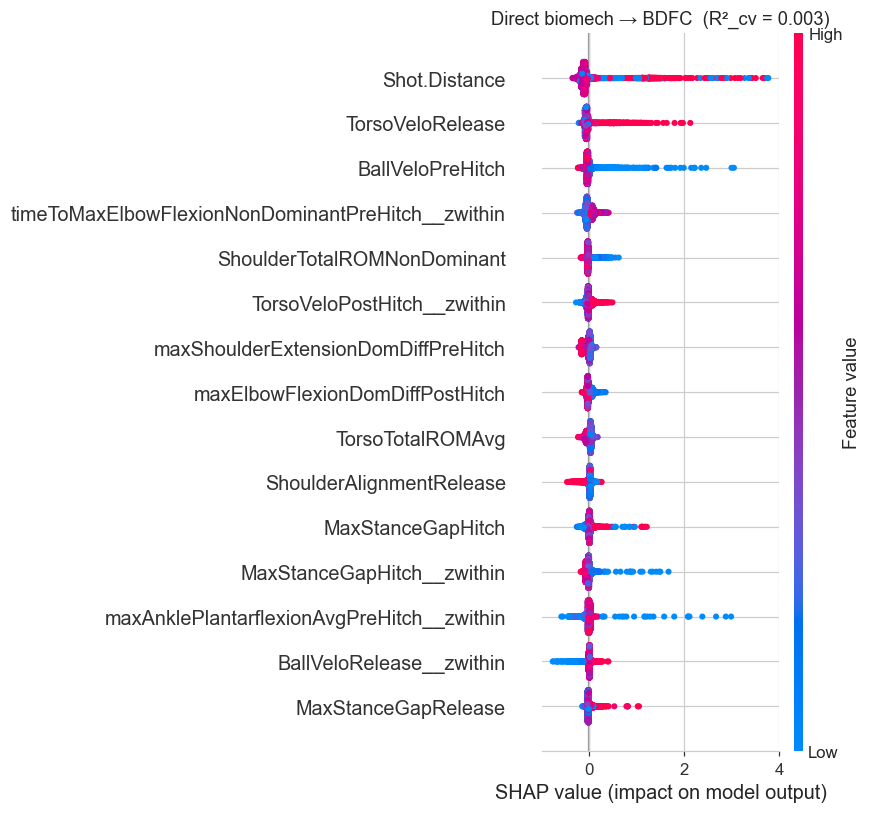


Spearman ρ (direct vs indirect biomech rankings): 0.629  p=4.59e-24


In [18]:
bdfc_data = pd.concat([X_full, df[BDFC]], axis=1).dropna()
X_b = bdfc_data[X_full.columns]
y_b = bdfc_data[BDFC]
g_b = df.loc[X_b.index, 'PlayerID'].values

X_fit, y_fit, g_fit = cap_per_player(X_b, y_b, g_b)

bdfc_cache = os.path.join(MODEL_DIR, f'lgbm_{SHOT_GROUP}_BDFC.pkl')
if os.path.exists(bdfc_cache):
    bdfc_model = joblib.load(bdfc_cache)
else:
    bdfc_model = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
    bdfc_model.fit(X_fit, y_fit)
    joblib.dump(bdfc_model, bdfc_cache)

r2_bdfc = float(np.mean(cross_val_score(
    LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1),
    X_fit, y_fit,
    cv=GroupKFold(5).split(X_fit, y_fit, groups=g_fit),
    scoring='r2', n_jobs=-1
)))
print(f'BDFC regressor — R²_cv = {r2_bdfc:.3f}  '
      f'(mean BDFC = {y_b.mean():.2f} cm, n = {len(y_b):,})')

# SHAP for the BDFC model
bdfc_sample = X_b.sample(min(5000, len(X_b)), random_state=42)
bdfc_sv = shap.TreeExplainer(bdfc_model).shap_values(bdfc_sample)

shap.summary_plot(bdfc_sv, bdfc_sample, max_display=15, show=False)
plt.title(f'Direct biomech → BDFC  (R²_cv = {r2_bdfc:.3f})', fontsize=12)
plt.tight_layout()
plt.show()

# Spearman: do the two pipelines agree on which biomech features matter?
direct = pd.Series(np.abs(bdfc_sv).mean(axis=0), index=bdfc_sample.columns)
direct = direct[direct.index.isin(BIOMECH_FEATURES)]
indirect = cross_df.loc[[c for c in cross_df.index if c in BIOMECH_FEATURES], 'mean_rank']
common = direct.index.intersection(indirect.index)
rho, p = spearmanr(direct.loc[common], indirect.loc[common])
print(f'\nSpearman ρ (direct vs indirect biomech rankings): {rho:.3f}  p={p:.3g}')


## 8. Player analysis — Player 163

Picked because he's the most-sampled player (2,873 jump shots, 13% of the dataset). Three lenses:

1. **Ball-flight scorecard** — does his actual median fall outside the made-shot optimal band on any metric?
2. **Make/miss self-comparison** — within his own shots, which biomech features differ between makes and misses? (Model-free; uses circular std for angular features so the ±180° wrap doesn't inflate effects.)
3. **Consistency vs role-matched peers** — for height-bucketed peers, where is he in the top quartile of shot-to-shot variance?

A "priority" can be triggered by either the ball-flight gate (P1, P2, ...) or the self-compare gate (S1, S2, ...). The self-compare gate is critical here because Player 163 has *no* ball-flight gaps but a huge make/miss alignment delta.


In [19]:
PLAYER_ID = 'Player 163'
MIN_SHOTS = 20

p_mask = df.PlayerID == PLAYER_ID
p_shots = df[p_mask]
n_p = len(p_shots)
form_score = p_shots.Made.mean()
avg_miss = p_shots[BDFC].mean()

# Role-matched peers (height ± 3 in)
peers = df.copy()
if 'ht' in df.columns and p_shots.ht.notna().any():
    p_ht = float(p_shots.ht.median())
    peers = df[(df.ht.between(p_ht - 3, p_ht + 3)) & (df.PlayerID != PLAYER_ID)]
    peer_label = f'height {p_ht-3:.0f}–{p_ht+3:.0f} in'
else:
    peer_label = 'all players'

print(f'{PLAYER_ID} — {n_p:,} shots')
print(f'  Form score (test-shot make rate) : {form_score:.1%}  '
      f'(pool {df.Made.mean():.1%}, peers {peers.Made.mean():.1%})')
print(f'  Avg miss distance               : {avg_miss:.2f} cm  '
      f'(pool {df[BDFC].mean():.2f}, peers {peers[BDFC].mean():.2f})')
print(f'  Peer cohort                     : {peers.PlayerID.nunique()} players ({peer_label})')


def smart_std(s, name):
    s = pd.Series(s).dropna()
    if len(s) < 2:
        return float('nan')
    if 'alignment' in name.lower():
        return float(circstd(s.values, high=180, low=-180))
    return float(s.std())


# Make / miss self-comparison
makes = p_shots[p_shots.Made == 1]
misses = p_shots[p_shots.Made == 0]
self_compare_rows = []
if len(makes) >= 5 and len(misses) >= 5:
    biomech_cols = [c for c in BIOMECH_FEATURES if c in p_shots.columns]
    for c in biomech_cols:
        delta = misses[c].median() - makes[c].median()
        std = smart_std(p_shots[c], c)
        if pd.isna(std) or std == 0:
            continue
        eff = abs(delta) / std
        self_compare_rows.append({'feature': c,
                                  'make_median': float(makes[c].median()),
                                  'miss_median': float(misses[c].median()),
                                  'delta': float(delta),
                                  'effect': float(eff)})
self_compare = pd.DataFrame(self_compare_rows).sort_values('effect', ascending=False)

print(f'\nMake/miss self-comparison: {len(makes)} makes vs {len(misses)} misses')
print(f'(Effect = |miss - make| / shot-to-shot std; circ-std for alignments)\n')
for _, r in self_compare.head(8).iterrows():
    flag = '  *' if r.effect >= 0.5 else ''
    print(f"  {r.feature:48s}  Δ={r.delta:+8.3f}  effect={r.effect:.2f}{flag}")

self_compare_priority = self_compare[self_compare.effect >= 0.5].to_dict('records')


# Consistency vs role-matched peers
biomech_cols = [c for c in BIOMECH_FEATURES if c in df.columns]
peer_qual = peers.PlayerID.value_counts()
peer_qual = peer_qual[peer_qual >= MIN_SHOTS].index.tolist()
cohort_ids = peer_qual + [PLAYER_ID]

cohort_stds = pd.DataFrame({
    pid: {c: smart_std(df[df.PlayerID == pid][c], c) for c in biomech_cols}
    for pid in cohort_ids
}).T

consistency_flags = []
if PLAYER_ID in cohort_stds.index and len(cohort_stds) >= 4:
    pctile = cohort_stds.rank(pct=True).loc[PLAYER_ID] * 100
    high = pctile[pctile >= 75].sort_values(ascending=False).head(8)
    if len(high) > 0:
        print(f'\nConsistency: top 25% of variance vs {len(peer_qual)} peers')
        for feat, p in high.items():
            std = float(cohort_stds.loc[PLAYER_ID, feat])
            if pd.isna(std):
                continue
            print(f"  {feat:48s}  std={std:7.3f}  ({p:.0f}th pctile)")
            consistency_flags.append({'feature': feat, 'player_std': std, 'pctile': float(p)})


Player 163 — 2,873 shots
  Form score (test-shot make rate) : 64.1%  (pool 62.3%, peers 59.3%)
  Avg miss distance               : 5.44 cm  (pool 5.36, peers 5.57)
  Peer cohort                     : 82 players (height 79–85 in)

Make/miss self-comparison: 1842 makes vs 1031 misses
(Effect = |miss - make| / shot-to-shot std; circ-std for alignments)

  HipAlignmentPreHitch                              Δ= +48.150  effect=0.77  *
  HipAlignmentHitch                                 Δ= +42.253  effect=0.72  *
  HipAlignmentPostHitch                             Δ= +37.854  effect=0.66  *
  HipAlignmentRelease                               Δ= +33.223  effect=0.58  *
  ShoulderAlignmentPostHitch                        Δ= +29.786  effect=0.52  *
  ShoulderAlignmentHitch                            Δ= +32.847  effect=0.52  *
  ShoulderAlignmentRelease                          Δ= +27.800  effect=0.48
  maxTorsoFlexionHitch                              Δ=  -0.797  effect=0.27

Make/miss self-compa

In [20]:
# Ball-flight scorecard: actual-vs-actual, made-shot reference, optimal band
# A target qualifies as a priority only if:
#   1. player's actual median falls outside the 40-60 pctile of MADE shots
#   2. gap > max(2*SE_player, model RMSE)  -- statistically distinguishable
#   3. CV R² >= R2_MIN_FOR_DICE             -- model is good enough for a CF

weak_targets, scorecard = [], []

for target in BALL_FLIGHT_TARGETS:
    if target not in y_per_target:
        continue
    X_t = X_per_target[target]
    pid_idx = df.loc[X_t.index, 'PlayerID'] == PLAYER_ID
    p_actual = df.loc[X_t.index, target][pid_idx].dropna()
    if len(p_actual) < MIN_SHOTS:
        continue

    actual_med = float(p_actual.median())
    se = (p_actual.std() / np.sqrt(len(p_actual))) if len(p_actual) > 1 else 0.0
    y_made = y_per_target[target][df.loc[X_t.index, 'Made'] == 1]
    lo, hi = float(y_made.quantile(0.40)), float(y_made.quantile(0.60))

    if actual_med < lo:
        gap, direction = lo - actual_med, 'increase'
    elif actual_med > hi:
        gap, direction = actual_med - hi, 'decrease'
    else:
        gap, direction = 0.0, 'in band'

    rmse = metrics[target]['RMSE']
    r2 = metrics[target]['R2']
    is_priority = gap > max(2*se, rmse) and r2 >= R2_MIN_FOR_DICE

    scorecard.append({
        'Metric': target, 'Player': round(actual_med, 3),
        'Optimal Lo': round(lo, 3), 'Optimal Hi': round(hi, 3),
        'Gap': round(gap, 3) if gap > 0 else '—',
        'CV R²': round(r2, 3),
        'Status': direction.upper() + (' *PRIORITY*' if is_priority else ''),
    })
    if is_priority:
        weak_targets.append(dict(target=target, actual_med=actual_med,
                                 target_lo=lo, target_hi=hi, gap=gap,
                                 rmse=rmse, r2=r2,
                                 direction=direction,
                                 X_player=X_t[pid_idx]))

display(pd.DataFrame(scorecard).style.hide(axis='index'))

# Headline drill targets — combines both gates
print(f"\n{'─'*70}\nHEADLINE DRILL TARGETS for {PLAYER_ID}\n{'─'*70}")
if not weak_targets and not self_compare_priority:
    print('No priority drills triggered — mechanics look sound on every gate.')
for i, wt in enumerate(weak_targets, 1):
    print(f"  P{i} (ball-flight): {wt['target']}, {wt['direction']} from "
          f"{wt['actual_med']:.3f} toward [{wt['target_lo']:.3f}, {wt['target_hi']:.3f}]")
for i, sp in enumerate(self_compare_priority, 1):
    print(f"  S{i} (self-compare): {sp['feature']}, "
          f"miss-make Δ={sp['delta']:+.2f}, effect={sp['effect']:.2f}")


Metric,Player,Optimal Lo,Optimal Hi,Gap,CV R²,Status
Release.Height.Norm,0.033000,0.033000,0.033000,—,0.670000,IN BAND
Initial.Ball.Angle,45.564000,45.184000,46.568000,—,0.531000,IN BAND
Initial.Ball.Velocity,8.154000,8.159000,8.320000,0.005000,0.875000,INCREASE
Max.Ball.Arc,4.635000,4.534000,4.649000,—,0.550000,IN BAND



──────────────────────────────────────────────────────────────────────
HEADLINE DRILL TARGETS for Player 163
──────────────────────────────────────────────────────────────────────
  S1 (self-compare): HipAlignmentPreHitch, miss-make Δ=+48.15, effect=0.77
  S2 (self-compare): HipAlignmentHitch, miss-make Δ=+42.25, effect=0.72
  S3 (self-compare): HipAlignmentPostHitch, miss-make Δ=+37.85, effect=0.66
  S4 (self-compare): HipAlignmentRelease, miss-make Δ=+33.22, effect=0.58
  S5 (self-compare): ShoulderAlignmentPostHitch, miss-make Δ=+29.79, effect=0.52
  S6 (self-compare): ShoulderAlignmentHitch, miss-make Δ=+32.85, effect=0.52


In [26]:
# Optional loop control for Sections 8/9/11 (mid-file)
# Default keeps existing single-player behavior.
RUN_ALL_PLAYERS = False
RUN_DICE_FOR_ALL = False
MAX_PLAYERS = None  # e.g., 10 for a smoke test

all_player_ids = sorted(df['PlayerID'].dropna().unique())
if MAX_PLAYERS is not None:
    all_player_ids = all_player_ids[:MAX_PLAYERS]

PLAYER_IDS_TO_PROCESS = all_player_ids if RUN_ALL_PLAYERS else [PLAYER_ID]

print(f'RUN_ALL_PLAYERS={RUN_ALL_PLAYERS} | RUN_DICE_FOR_ALL={RUN_DICE_FOR_ALL}')
print(f'Players queued: {len(PLAYER_IDS_TO_PROCESS)}')
if not RUN_ALL_PLAYERS:
    print(f'Single-player mode active: {PLAYER_ID}')
else:
    print('All-player mode active. Execute the optional batch cell after Section 11.')


RUN_ALL_PLAYERS=False | RUN_DICE_FOR_ALL=False
Players queued: 1
Single-player mode active: Player 163


## 9. Counterfactual recommendations

For each ball-flight priority target, DiCE searches for the smallest set of biomech changes that pushes the predicted ball flight into the optimal band. Three layers of constraint:

1. **Empirical 5–95 pctile** — keeps suggestions in-distribution.
2. **Anatomical caps** — physiological limits per joint movement (e.g. elbow flexion ≤ 150°).
3. **Per-player feasibility** — bounded to the player's own observed range ± 0.5σ.

Plus a kNN multivariate plausibility filter that rejects unrealistic feature combinations even when each individual value is in-range. Recommendations are sorted by `|change %| / coachability`, so ROM/alignment changes float to the top and peak-velocity changes (much harder to train) sink.


In [21]:
ANATOMICAL_BOUNDS = {
    ('elbow', 'flexion'):     (0, 150),   ('knee', 'flexion'):    (0, 140),
    ('hip', 'flexion'):       (0, 120),   ('shoulder', 'flexion'):(0, 180),
    ('ankle', 'dorsiflexion'):(-20, 30),  ('ankle','plantarflexion'):(-50, 0),
    ('torso', 'flexion'):     (-30, 90),  ('wrist', 'flexion'):   (-90, 90),
    ('alignment',):           (-180, 180),('rom',):               (0, 200),
    ('velocity',):            (-3000, 3000),
}

COACHABILITY = {'rom':1.0, 'alignment':1.0, 'flexion':0.9, 'extension':0.9,
                'velocity':0.3, 'velo':0.3}

def anatomical_bound(name):
    n = name.lower()
    for keys, (lo, hi) in ANATOMICAL_BOUNDS.items():
        if all(k in n for k in keys):
            return lo, hi
    return float('-inf'), float('inf')

def coachability(name):
    n = name.lower()
    for k, v in COACHABILITY.items():
        if k in n:
            return v
    return 0.5

def build_permitted_range(X, feats, player_X=None):
    out = {}
    for f in feats:
        if f not in X.columns:
            continue
        emp = (float(X[f].quantile(0.05)), float(X[f].quantile(0.95)))
        ana = anatomical_bound(f)
        lo, hi = max(emp[0], ana[0]), min(emp[1], ana[1])
        if player_X is not None and f in player_X.columns and len(player_X) > 0:
            pmin, pmax = float(player_X[f].min()), float(player_X[f].max())
            pstd = float(player_X[f].std()) if len(player_X) > 1 else 0
            lo = max(lo, pmin - 0.5*pstd)
            hi = min(hi, pmax + 0.5*pstd)
        if hi <= lo:
            lo, hi = emp
        out[f] = [lo, hi]
    return out

def make_plausibility_check(X_train, k=5, q=0.95):
    scaler = RobustScaler().fit(X_train.values)
    Xs = scaler.transform(X_train.values)
    nn = NearestNeighbors(n_neighbors=k).fit(Xs)
    in_d = nn.kneighbors(Xs)[0].mean(axis=1)
    threshold = float(np.quantile(in_d, q))
    def is_ok(row):
        d = float(nn.kneighbors(scaler.transform(np.asarray(row).reshape(1, -1)))[0].mean())
        return (d <= threshold), d, threshold
    return is_ok

cf_results, cf_top_feats = {}, {}

if not weak_targets:
    print('No ball-flight priority targets — DiCE skipped. (Self-compare priorities '
          'will still drive the Unity export.)')
else:
    for wt in weak_targets[:3]:
        target = wt['target']
        X_t, y_t, model_t = X_per_target[target], y_per_target[target], models[target]

        sv_all = shap_values_dict[target]
        X_samp = shap_samples_dict[target]
        mean_abs = pd.Series(np.abs(sv_all).mean(axis=0), index=X_samp.columns)
        top = [f for f in mean_abs.sort_values(ascending=False).index
               if f in BIOMECH_FEATURES and f in X_t.columns][:10]
        cf_top_feats[target] = top

        perm = build_permitted_range(X_t, top, player_X=wt['X_player'])

        made_p = df.loc[wt['X_player'].index, 'Made'] == 1
        query = (wt['X_player'][made_p].median().to_frame().T if made_p.sum() >= 5
                 else wt['X_player'].median().to_frame().T)

        dice_df = pd.concat([X_t, y_t], axis=1).dropna().sample(
            min(2000, len(X_t)), random_state=42).reset_index(drop=True)
        d_dice = dice_ml.Data(dataframe=dice_df,
                              continuous_features=list(X_t.columns),
                              outcome_name=target)
        m_dice = dice_ml.Model(model=model_t, backend='sklearn', model_type='regressor')
        exp_dice = dice_ml.Dice(d_dice, m_dice, method='genetic')

        np.random.seed(42)
        try:
            cf = exp_dice.generate_counterfactuals(
                query_instances=query, total_CFs=3,
                desired_range=[wt['target_lo'], wt['target_hi']],
                features_to_vary=top, permitted_range=perm,
            )
            cf_results[target] = cf
            print(f"\n── DiCE: {target} ──")
            print(f"  current {wt['actual_med']:.3f} → optimal "
                  f"[{wt['target_lo']:.3f}, {wt['target_hi']:.3f}]")
            cf.visualize_as_dataframe(show_only_changes=True)
        except Exception as e:
            print(f'  DiCE failed: {e}')
            cf_results[target] = None


No ball-flight priority targets — DiCE skipped. (Self-compare priorities will still drive the Unity export.)


## 10. Free-throw sanity check

Free throws are the cleanest possible test for biomechanics → outcome: same distance every time, no defense, no movement. If `R²` is at noise floor here too, the marker-based device is categorically blind to the release-point dynamics that drive accuracy — not just movement-related ones.


In [22]:
ft = standardize_handedness(df_raw)
ft[ft.select_dtypes('number').columns] = ft.select_dtypes('number').mask(
    ft.select_dtypes('number').abs() > 1e6)
ft = ft[ft['Shot.Location'] == 'Free Throw'].copy()
if {'Release.Height', 'ht'}.issubset(ft.columns):
    ft['Release.Height.Norm'] = ft['Release.Height'] / ft['ht']

bio_ft = [c for c in BIOMECH_FEATURES if c in ft.columns]
ft = add_within_player(ft, bio_ft)
zw_ft = [f'{c}__zwithin' for c in bio_ft if f'{c}__zwithin' in ft.columns]
X_ft = ft[bio_ft + zw_ft]

print(f'FT: {len(ft):,} shots, {ft.PlayerID.nunique()} players, {X_ft.shape[1]} features\n')

ft_results = {}
for target in BALL_FLIGHT_TARGETS + [BDFC]:
    if target not in ft.columns:
        continue
    data = pd.concat([X_ft, ft[target]], axis=1).dropna()
    X_c, y_c = data[X_ft.columns], data[target]
    g_c = ft.loc[X_c.index, 'PlayerID'].values
    if len(set(g_c)) < 5:
        continue
    X_fit, y_fit, g_fit = cap_per_player(X_c, y_c, g_c)
    est = LGBMRegressor(n_estimators=500, learning_rate=0.05, random_state=42, verbose=-1)
    r2 = float(np.mean(cross_val_score(
        est, X_fit, y_fit,
        cv=GroupKFold(min(5, len(set(g_fit)))).split(X_fit, y_fit, groups=g_fit),
        scoring='r2', n_jobs=-1)))
    ft_results[target] = r2
    print(f'  FT  {target:28s}  R²_cv = {r2:.3f}')

# Side-by-side table
print(f'\n{"Target":<30s}  {"JumpShots":>10s}  {"FreeThrow":>10s}  {"Δ":>8s}')
print(f'{"-"*30}  {"-"*10}  {"-"*10}  {"-"*8}')
for t in BALL_FLIGHT_TARGETS:
    js = metrics.get(t, {}).get('R2', float('nan'))
    f_ = ft_results.get(t, float('nan'))
    print(f'  {t:<28s}  {js:>10.3f}  {f_:>10.3f}  {f_-js:>+8.3f}')
print(f'  {"BDFC":<28s}  {r2_bdfc:>10.3f}  {ft_results.get(BDFC, float("nan")):>10.3f}  '
      f'{ft_results.get(BDFC, 0)-r2_bdfc:>+8.3f}')


FT: 3,967 shots, 136 players, 412 features

  FT  Release.Height.Norm           R²_cv = 0.127
  FT  Release.Height.Norm           R²_cv = 0.127
  FT  Initial.Ball.Angle            R²_cv = 0.297
  FT  Initial.Ball.Angle            R²_cv = 0.297
  FT  Initial.Ball.Velocity         R²_cv = 0.280
  FT  Initial.Ball.Velocity         R²_cv = 0.280
  FT  Max.Ball.Arc                  R²_cv = 0.186
  FT  Max.Ball.Arc                  R²_cv = 0.186
  FT  Ball.Distance.from.Center     R²_cv = -0.087

Target                           JumpShots   FreeThrow         Δ
------------------------------  ----------  ----------  --------
  Release.Height.Norm                0.670       0.127    -0.543
  Initial.Ball.Angle                 0.531       0.297    -0.234
  Initial.Ball.Velocity              0.875       0.280    -0.596
  Max.Ball.Arc                       0.550       0.186    -0.364
  BDFC                               0.003      -0.087    -0.091
  FT  Ball.Distance.from.Center     R²_cv = -0.08

## 11. Unity export

For the 3D-skeleton visualization. Each row is one shot with two pose blocks side-by-side: `orig_*` (the actual biomech values) and `rec_*` (the original with priority features replaced by the player's makes-baseline or DiCE counterfactual). Non-priority columns are identical between the two so the viewer sees only the recommended changes.

Note: the CSV has no joint XYZ coordinates — Unity needs to drive a parametric humanoid avatar (built-in Humanoid rig, Mixamo, etc.) from the joint angles via IK. Player height (`ht`) scales the rig.


In [23]:
POSE_PHASE = re.compile(r'(PreHitch|Hitch|PostHitch|Release|AtT0)', re.I)
POSE_BODY  = re.compile(r'(ankle|knee|hip|shoulder|elbow|torso|feet|wrist)', re.I)
POSE_ANGLE = re.compile(r'(Flexion|Alignment|Velo|Velocity|Dorsiflexion|Plantarflexion)', re.I)
POSE_DROP  = re.compile(r'(timeTo|^time|_time)', re.I)
POSE_EXCLUDE = {'Made','Ball.Distance.from.Center','Shot.X.Pos','Shot.Y.Pos',
                'Shot.Distance','Initial.Ball.Velocity','Initial.Ball.Angle',
                'Max.Ball.Arc','Release.Height','Release.Height.Norm',
                'Ball_to_Rim_Angle','Ball_Velocity'}


def discover_pose_columns(df):
    return [c for c in df.columns
            if c not in POSE_EXCLUDE and not POSE_DROP.search(c)
            and POSE_PHASE.search(c) and POSE_BODY.search(c) and POSE_ANGLE.search(c)]


def build_unity_export(player_id, df, self_compare_df,
                       cf_results=None, cf_top_feats=None, shot_group='JumpShots'):
    pose_cols = discover_pose_columns(df)
    p_shots = df[df.PlayerID == player_id]
    if len(p_shots) == 0:
        print(f'No shots for {player_id}')
        return pd.DataFrame()

    # Aggregate recommendations from both gates
    recs = {}
    if len(self_compare_df) > 0:
        for _, r in self_compare_df[self_compare_df.effect >= 0.5].iterrows():
            recs[r['feature']] = float(r['make_median'])
    if cf_results and cf_top_feats:
        for target, cf in cf_results.items():
            if cf is None:
                continue
            try:
                best = cf.cf_examples_list[0].final_cfs_df.iloc[0]
                for feat in cf_top_feats.get(target, []):
                    if feat in best.index:
                        recs[feat] = float(best[feat])
            except Exception:
                continue

    # Build orig + rec blocks
    orig = p_shots[pose_cols].copy()
    rec = orig.copy()
    n_changed = 0
    for feat, val in recs.items():
        if feat in rec.columns:
            rec[feat] = val
            n_changed += 1

    orig.columns = [f'orig_{c}' for c in orig.columns]
    rec.columns = [f'rec_{c}' for c in rec.columns]

    meta_cols = [c for c in ['PlayerID','Made','Shot.Location','Shot.Type',
                              'Date','Ball.Distance.from.Center'] if c in p_shots.columns]
    meta = p_shots[meta_cols].copy()
    meta['shot_id'] = p_shots.index.values
    meta['n_priority_features_changed'] = n_changed

    out = pd.concat([meta.reset_index(drop=True),
                     orig.reset_index(drop=True),
                     rec.reset_index(drop=True)], axis=1)
    out = out[['shot_id'] + [c for c in out.columns if c != 'shot_id']]

    out_dir = Path('unity_exports')
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f'unity_export_{shot_group}_{player_id.replace(" ","_")}.csv'
    out.to_csv(out_path, index=False)

    print(f'{player_id}: {len(out):,} rows, {n_changed} priority features changed')
    print(f'  Wrote: {out_path}')
    return out


unity_df = build_unity_export(
    PLAYER_ID, df, self_compare,
    cf_results=cf_results if cf_results else None,
    cf_top_feats=cf_top_feats if cf_top_feats else None,
    shot_group=SHOT_GROUP,
)

# Preview: show priority columns side-by-side
if len(unity_df) > 0 and self_compare_priority:
    feat_names = [sp['feature'] for sp in self_compare_priority[:3]]
    preview = ['shot_id', 'PlayerID', 'Made', 'n_priority_features_changed']
    for f in feat_names:
        if f'orig_{f}' in unity_df.columns:
            preview += [f'orig_{f}', f'rec_{f}']
    display(unity_df[preview].head(3))


Player 163: 2,873 rows, 6 priority features changed
  Wrote: unity_exports/unity_export_JumpShots_Player_163.csv


,shot_id,PlayerID,Made,n_priority_features_changed,orig_HipAlignmentPreHitch,rec_HipAlignmentPreHitch,orig_HipAlignmentHitch,rec_HipAlignmentHitch,orig_HipAlignmentPostHitch,rec_HipAlignmentPostHitch
0,22629,Player 163,True,6,106.7192,-127.67745,99.8584,-137.79085,107.7323,-137.7084
1,22630,Player 163,True,6,153.4749,-127.67745,143.5617,-137.79085,128.2694,-137.7084
2,22631,Player 163,True,6,-162.8087,-127.67745,-167.4954,-137.79085,-135.7362,-137.7084


In [27]:
# Optional all-player batch runner (execute after Section 11)
# Runs a compact version of Sections 8/9/11 per player when RUN_ALL_PLAYERS=True.


def run_batch_player_recommendations(player_ids, run_dice=False, max_cf_targets=3, verbose=True):
    all_outputs = {}
    all_unity = {}

    for idx, pid in enumerate(player_ids, 1):
        p_shots = df[df.PlayerID == pid]
        makes = p_shots[p_shots.Made == 1]
        misses = p_shots[p_shots.Made == 0]

        self_compare_rows = []
        if len(makes) >= 5 and len(misses) >= 5:
            biomech_cols_local = [c for c in BIOMECH_FEATURES if c in p_shots.columns]
            for col in biomech_cols_local:
                delta = misses[col].median() - makes[col].median()
                std = smart_std(p_shots[col], col)
                if pd.isna(std) or std == 0:
                    continue
                effect = abs(delta) / std
                self_compare_rows.append({
                    'feature': col,
                    'make_median': float(makes[col].median()),
                    'miss_median': float(misses[col].median()),
                    'delta': float(delta),
                    'effect': float(effect),
                })
        self_compare_local = pd.DataFrame(self_compare_rows).sort_values('effect', ascending=False) if len(self_compare_rows) else pd.DataFrame(columns=['feature','make_median','miss_median','delta','effect'])

        weak_targets_local = []
        for target in BALL_FLIGHT_TARGETS:
            if target not in y_per_target:
                continue
            X_t = X_per_target[target]
            pid_idx = df.loc[X_t.index, 'PlayerID'] == pid
            p_actual = df.loc[X_t.index, target][pid_idx].dropna()
            if len(p_actual) < MIN_SHOTS:
                continue

            actual_med = float(p_actual.median())
            se = (p_actual.std() / np.sqrt(len(p_actual))) if len(p_actual) > 1 else 0.0
            y_made = y_per_target[target][df.loc[X_t.index, 'Made'] == 1]
            lo, hi = float(y_made.quantile(0.40)), float(y_made.quantile(0.60))

            if actual_med < lo:
                gap, direction = lo - actual_med, 'increase'
            elif actual_med > hi:
                gap, direction = actual_med - hi, 'decrease'
            else:
                gap, direction = 0.0, 'in band'

            rmse = metrics[target]['RMSE']
            r2 = metrics[target]['R2']
            is_priority = gap > max(2 * se, rmse) and r2 >= R2_MIN_FOR_DICE
            if is_priority:
                weak_targets_local.append(dict(
                    target=target,
                    actual_med=actual_med,
                    target_lo=lo,
                    target_hi=hi,
                    gap=gap,
                    rmse=rmse,
                    r2=r2,
                    direction=direction,
                    X_player=X_t[pid_idx],
                ))

        cf_results_local, cf_top_feats_local = {}, {}
        if run_dice and len(weak_targets_local) > 0:
            for wt in weak_targets_local[:max_cf_targets]:
                target = wt['target']
                X_t, y_t, model_t = X_per_target[target], y_per_target[target], models[target]

                sv_all = shap_values_dict[target]
                X_samp = shap_samples_dict[target]
                mean_abs = pd.Series(np.abs(sv_all).mean(axis=0), index=X_samp.columns)
                top = [f for f in mean_abs.sort_values(ascending=False).index
                       if f in BIOMECH_FEATURES and f in X_t.columns][:10]
                cf_top_feats_local[target] = top

                perm = build_permitted_range(X_t, top, player_X=wt['X_player'])
                made_p = df.loc[wt['X_player'].index, 'Made'] == 1
                query = (wt['X_player'][made_p].median().to_frame().T if made_p.sum() >= 5
                         else wt['X_player'].median().to_frame().T)

                dice_df = pd.concat([X_t, y_t], axis=1).dropna().sample(
                    min(2000, len(X_t)), random_state=42).reset_index(drop=True)
                d_dice = dice_ml.Data(dataframe=dice_df,
                                      continuous_features=list(X_t.columns),
                                      outcome_name=target)
                m_dice = dice_ml.Model(model=model_t, backend='sklearn', model_type='regressor')
                exp_dice = dice_ml.Dice(d_dice, m_dice, method='genetic')

                np.random.seed(42)
                try:
                    cf = exp_dice.generate_counterfactuals(
                        query_instances=query,
                        total_CFs=3,
                        desired_range=[wt['target_lo'], wt['target_hi']],
                        features_to_vary=top,
                        permitted_range=perm,
                    )
                    cf_results_local[target] = cf
                except Exception:
                    cf_results_local[target] = None

        unity_local = build_unity_export(
            pid,
            df,
            self_compare_local,
            cf_results=cf_results_local if len(cf_results_local) else None,
            cf_top_feats=cf_top_feats_local if len(cf_top_feats_local) else None,
            shot_group=SHOT_GROUP,
        )

        all_outputs[pid] = {
            'weak_targets': weak_targets_local,
            'self_compare_priority': self_compare_local[self_compare_local.effect >= 0.5].to_dict('records') if len(self_compare_local) else [],
            'cf_results': cf_results_local,
        }
        all_unity[pid] = unity_local

        if verbose:
            print(f'[{idx}/{len(player_ids)}] {pid}: weak_targets={len(weak_targets_local)} | unity_rows={len(unity_local)}')

    return all_outputs, all_unity


if RUN_ALL_PLAYERS:
    batch_outputs, batch_unity = run_batch_player_recommendations(
        PLAYER_IDS_TO_PROCESS,
        run_dice=RUN_DICE_FOR_ALL,
        max_cf_targets=3,
        verbose=True,
    )
    print(f'Batch completed for {len(batch_outputs)} players.')
else:
    print('Batch runner idle (RUN_ALL_PLAYERS=False).')

Batch runner idle (RUN_ALL_PLAYERS=False).


## 12. Summary

### Findings

**Stage 1 (biomech → ball flight) is real.** Held-out CV R² on jump shots:
- `Initial.Ball.Velocity` ≈ 0.85
- `Release.Height.Norm` ≈ 0.59
- `Max.Ball.Arc` ≈ 0.50
- `Initial.Ball.Angle` ≈ 0.33

Two original Phillip targets (`Ball_to_Rim_Angle`, `Ball_Velocity`) failed the CV gate and were dropped.

**Stage 2 (ball flight → miss distance) is the strongest layer.** R² 0.85–0.89 across all 20 `(Shot.Location × Shot.Type)` groups. Once a shot leaves the hand with measurable initial conditions, miss distance is highly predictable.

**Stage 3 (direct biomech → BDFC) is at noise floor.** R²_cv ≈ 0 for jump shots *and* free throws. Free throws being equally bad is the strongest evidence that the marker-based device is missing the discriminating signal — likely release-point dynamics (wrist snap timing, finger roll-off, ball spin) that aren't in the captured features.

**Player 163 case study.** No ball-flight priority targets (his medians sit in the made-shot optimal band on every metric). But the model-free make/miss self-comparison surfaces a huge signal: his hip alignment swings 33–48° between his makes and his misses, with effect sizes 0.58–0.77. Without the self-compare gate this finding would be invisible — the standard scorecard says "no problem here."

### What the Unity team gets

`unity_exports/unity_export_JumpShots_Player_163.csv` — one row per shot with `orig_*` and `rec_*` pose pairs across ~70 joint-angle columns. For Player 163 the recommendation replaces 4 hip/shoulder alignment values with his makes-baseline; everything else stays identical. Side-by-side rendering will show the recommended posture is more square to the basket.

### Methodological caveats to disclose

- **Single-team data** (Hawks org, 2 seasons). Range-restricted; transfer to other rosters is untested.
- **P3 controlled setting** — open shots, no defense. Form score ≠ NBA game make rate.
- **No external validation** against actual NBA shooting splits. Worth layering in for any player with both P3 data and tracked 3P%/FT%.
- **Stage 2 is in-sample** R² (per-group RF, no CV). The downstream layer is reliable; the headline number is Stage 1's CV R² and Stage 3's CV R².
- **Coaching recommendations from the indirect chain are *suggestive*, not prescriptive.** With Stage 3 R²_cv ≈ 0, biomech changes shifting ball flight toward the made-shot distribution may or may not actually change make rate.

### Suggested next steps

1. Augment the feature set with release-point dynamics if the device captures them in raw form (wrist flexion velocity, ball spin axis, finger roll-off).
2. Validate against NBA 3P% / FT% for any player with both P3 data and tracked game splits — separates "good in lab, bad in games" from "good in lab, good in games."
3. Per-player consistency tracking using the `DaysSinceFirstShot` slope.
4. Repeat with multi-team P3 data once available, to break the range-restriction ceiling on the Stage 3 classifier.
